# T2 — 랭킹 목적함수 + DART (직접 AUC 최적화)

> **질문:** 지금껏 전부 `binary`(logloss)였다. 지표는 **AUC=순위** → 순위를 직접 최적화하는 **`rank:pairwise`(랭킹)** 가 logloss보다 AUC를 더 끌어올리나? **DART**(트리 드롭아웃=다른 정규화)는?
>
> **멤버:** 기준 3트리(lgb/cat/xgb, binary) + **T2 변이 2종** — `lgb_dart`(DART), `xgb_rank`(rank:pairwise).\n>\n> *주: LightGBM `lambdarank`는 한 그룹당 10,000행 상한(행수 제한, 실측 확인)이라 17만 단일그룹 불가 → 랭킹 레버는 XGBoost `rank:pairwise`로 검정. XGB 기본 페어 샘플링은 대형 단일그룹서 언더핏하므로 `lambdarank_num_pair_per_sample=8`+`pair_method="mean"`으로 보정(미보정 0.745 → 보정 0.832, pointwise 0.843 수준).*
>
> **구현 디테일(필수):** 랭킹 목적함수는 **`group` 정의 필수** — 전체 행을 **단일 그룹 `group=[N]`** 으로 줘야 AUC형이 됨. 랭킹 모델 출력은 확률이 아니라 점수라 **모든 OOF/test를 랭크 정규화**한 뒤 블렌드(AUC는 순위 기반이라 자연스러움).
>
> ⚠️ `scale_pos_weight`/`is_unbalance`는 **AUC엔 거의 무효**(확률만 바꿈)라 T2 레버에서 제외. 실제 레버 = **랭킹 목적함수 + DART.**
>
> **게이트(5절):** 결정지표 = (blend+T2 − 3트리블렌드) 증분 → **페어드 부트스트랩 CI>0** + FAST→FULL 안정 + (확정 시)멀티시드. 가중치>0만으로는 채택 아님.
>
> CPU로 충분(GPU 불필요). FAST로 방향 → FULL 확정.

## 1. 셋업

In [3]:
import re, os, glob, warnings
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import rankdata
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool
import xgboost as xgb
warnings.filterwarnings("ignore")
def kfont():
    try:
        import koreanize_matplotlib; return "koreanize_matplotlib"
    except Exception: pass
    from matplotlib import font_manager
    for c in ["NanumGothic","Malgun Gothic","AppleGothic"]:
        if any(c in f.name for f in font_manager.fontManager.ttflist): matplotlib.rcParams["font.family"]=c; return c
    matplotlib.rcParams["axes.unicode_minus"]=False; return None
print("폰트:",kfont() or "미설정")

폰트: 미설정


## 2. 데이터 + 설정

In [4]:
csvs=sorted(glob.glob("/kaggle/input/**/*.csv",recursive=True)) or sorted(glob.glob("**/*.csv",recursive=True))
def pick(*ks):
    for p in csvs:
        if all(k in os.path.basename(p).lower() for k in ks): return p
train=pd.read_csv(pick("train") or csvs[0]); test=pd.read_csv(pick("test"))
sp=pick("sample") or pick("submission"); sample_sub=pd.read_csv(sp) if sp and "test" not in os.path.basename(sp).lower() else None
print("train",train.shape,"| test",test.shape)

SEED=42; N_SPLITS=5
FAST=True              # True: 3fold·짧은 라운드(방향). 확정 시 False
RUN_MULTISEED=False    # 멀티시드 게이트(무거움). seed42+게이트 먼저 보고 켜기
BOOT_N=1000            # 페어드 부트스트랩 반복
if FAST: N_SPLITS=3
print(f"FAST={FAST} | SEED={SEED} | N_SPLITS={N_SPLITS} | RUN_MULTISEED={RUN_MULTISEED}")

train (256351, 69) | test (90067, 68)
FAST=True | SEED=42 | N_SPLITS=3 | RUN_MULTISEED=False


## 3. 컬럼/매핑 + 트리 전처리(라벨인코딩)

In [5]:
TARGET="임신 성공 여부"; ID_COL="ID"; COL_PROC="특정 시술 유형"; COL_RSN="배아 생성 주요 이유"
NOMINAL_COLS=["시술 시기 코드","시술 유형","배란 유도 유형","난자 출처","정자 출처"]
ORDINAL_COUNT_COLS=["총 시술 횟수","클리닉 내 총 시술 횟수","IVF 시술 횟수","DI 시술 횟수",
 "총 임신 횟수","IVF 임신 횟수","DI 임신 횟수","총 출산 횟수","IVF 출산 횟수","DI 출산 횟수"]
AGE_MAPS={"시술 당시 나이":{"만18-34세":0,"만35-37세":1,"만38-39세":2,"만40-42세":3,"만43-44세":4,"만45-50세":5,"알 수 없음":-1},
 "난자 기증자 나이":{"만20세 이하":0,"만21-25세":1,"만26-30세":2,"만31-35세":3,"만36-40세":4,"만41-45세":5,"알 수 없음":-1},
 "정자 기증자 나이":{"만20세 이하":0,"만21-25세":1,"만26-30세":2,"만31-35세":3,"만36-40세":4,"만41-45세":5,"알 수 없음":-1}}
COUNT_MAP={"0회":0,"1회":1,"2회":2,"3회":3,"4회":4,"5회":5,"6회 이상":6}
_tp=lambda s: [] if pd.isna(s) else [t.strip() for t in re.split(r"[/:]",str(s)) if t.strip()]
y=train[TARGET].astype(int).values
folds=list(StratifiedKFold(N_SPLITS,shuffle=True,random_state=SEED).split(train,y))

def fit_tree(tr):
    st={}; ig={TARGET,ID_COL}
    st["dead"]=[c for c in tr.columns if c not in ig and tr[c].nunique(dropna=True)<=1]
    st["sparse"]=[c for c in tr.columns if c not in ig and c not in st["dead"] and tr[c].isna().mean()>0.98]
    st["label_cats"]={c:pd.Index(tr[c].astype("category").cat.categories) for c in NOMINAL_COLS if c in tr}
    st["proc_vocab"]=sorted({t for L in tr[COL_PROC].apply(_tp) for t in L})
    return st
def tf_tree(df,st):
    df=df.copy()
    if TARGET in df: df=df.drop(columns=[TARGET])
    df["is_DI"]=(df["시술 유형"]=="DI").astype(int)
    df=df.drop(columns=[c for c in st["dead"] if c in df.columns])
    for c in st["sparse"]:
        if c in df: df[f"{c}_있음"]=df[c].notna().astype(int); df=df.drop(columns=[c])
    for c in ORDINAL_COUNT_COLS:
        if c in df: df[c]=df[c].map(COUNT_MAP)
    for c,m in AGE_MAPS.items():
        if c in df: df[c]=df[c].map(m)
    cats=[]
    for c,cc in st["label_cats"].items():
        if c in df: df[c]=pd.Categorical(df[c],categories=cc).codes.astype("int32"); cats.append(c)
    ts=df[COL_PROC].apply(_tp)
    for v in st["proc_vocab"]: df[f"proc_{v}"]=ts.apply(lambda L,v=v:int(v in L))
    df=df.drop(columns=[COL_PROC])
    if COL_RSN in df: df=df.drop(columns=[COL_RSN])
    df=df.drop(columns=[c for c in [ID_COL] if c in df.columns])
    obj=[c for c in df.columns if df[c].dtype==object]
    if obj: df=df.drop(columns=obj)
    for c in cats: df[c]=df[c].fillna(-1).astype("int32")
    return df,[c for c in cats if c in df.columns]

st=fit_tree(train); Xtr,cats=tf_tree(train,st); Xte,_=tf_tree(test,st); Xte=Xte.reindex(columns=Xtr.columns)
for c in cats: Xte[c]=Xte[c].fillna(-1).astype("int32")
print("피처",Xtr.shape[1],"| 범주형",len(cats))

피처 72 | 범주형 5


## 4. 멤버 OOF — 기준 3트리(binary) + T2 변이 3종

같은 fold에서 5개 멤버를 학습. 랭킹 모델은 **단일 그룹**으로, 모든 출력은 **랭크 정규화**해 스케일을 통일.

In [6]:
def runr(p): return rankdata(p)/len(p)   # 랭크 정규화(AUC 블렌드용)

def members_oof(train,test,folds,cats,Xtr,Xte,fast):
    yy=train[TARGET].astype(int).values; n=len(folds)
    nr=200 if fast else 2500; nd=200 if fast else 800; stop=40 if fast else 100
    names=["lgb_bin","cat_bin","xgb_bin","lgb_dart","xgb_rank"]
    oof={m:np.zeros(len(train)) for m in names}; tst={m:np.zeros(len(test)) for m in names}
    for k,(tri,vai) in enumerate(folds):
        Xt,Xv,yt,yv=Xtr.iloc[tri],Xtr.iloc[vai],yy[tri],yy[vai]
        d=lgb.Dataset(Xt,yt,categorical_feature=cats or "auto"); dv=lgb.Dataset(Xv,yv,reference=d)
        m=lgb.train(dict(objective="binary",metric="auc",learning_rate=0.05,num_leaves=63,
                         feature_fraction=0.8,bagging_fraction=0.8,bagging_freq=1,min_child_samples=50,verbose=-1,seed=42),
                    d,num_boost_round=nr,valid_sets=[dv],callbacks=[lgb.early_stopping(stop,verbose=False),lgb.log_evaluation(0)])
        oof["lgb_bin"][vai]=m.predict(Xv); tst["lgb_bin"]+=m.predict(Xte)/n
        cm=CatBoostClassifier(iterations=nr,learning_rate=0.05,depth=6,verbose=0,random_seed=42,early_stopping_rounds=stop)
        cm.fit(Pool(Xt,yt,cat_features=cats),eval_set=Pool(Xv,yv,cat_features=cats))
        oof["cat_bin"][vai]=cm.predict_proba(Xv)[:,1]; tst["cat_bin"]+=cm.predict_proba(Xte)[:,1]/n
        xm=xgb.XGBClassifier(n_estimators=nr,learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8,
                             tree_method="hist",eval_metric="auc",early_stopping_rounds=stop,random_state=42)
        xm.fit(Xt,yt,eval_set=[(Xv,yv)],verbose=False)
        oof["xgb_bin"][vai]=xm.predict_proba(Xv)[:,1]; tst["xgb_bin"]+=xm.predict_proba(Xte)[:,1]/n
        # T2-a: LGBM DART (binary, 고정 라운드 — dart는 early stop 부적합)
        md_=lgb.train(dict(objective="binary",metric="auc",boosting="dart",learning_rate=0.1,num_leaves=63,
                           drop_rate=0.1,skip_drop=0.5,feature_fraction=0.8,bagging_fraction=0.8,bagging_freq=1,verbose=-1,seed=42),
                      lgb.Dataset(Xt,yt,categorical_feature=cats or "auto"),num_boost_round=nd)
        oof["lgb_dart"][vai]=md_.predict(Xv); tst["lgb_dart"]+=md_.predict(Xte)/n
        # T2-b: XGB rank:pairwise (단일 그룹) — ★ 페어 샘플링 충분히(기본값은 대형그룹서 언더핏)
        dtr=xgb.DMatrix(Xt,label=yt); dtr.set_group([len(Xt)])
        dvr=xgb.DMatrix(Xv,label=yv); dvr.set_group([len(Xv)])
        xr=xgb.train(dict(objective="rank:pairwise",eval_metric="auc",max_depth=6,eta=0.05,
                          subsample=0.8,colsample_bytree=0.8,tree_method="hist",seed=42,
                          lambdarank_num_pair_per_sample=8,lambdarank_pair_method="mean"),
                     dtr,num_boost_round=nr,evals=[(dvr,"e")],early_stopping_rounds=stop,verbose_eval=False)
        _bi=getattr(xr,"best_iteration",None); _ir=(0,(_bi if _bi is not None else nr-1)+1)  # 명시적 반복범위
        oof["xgb_rank"][vai]=xr.predict(xgb.DMatrix(Xv),iteration_range=_ir); tst["xgb_rank"]+=xr.predict(xgb.DMatrix(Xte),iteration_range=_ir)/n
        print(f"  fold{k} done")
    for m in names: oof[m]=runr(oof[m]); tst[m]=runr(tst[m])   # 랭크 정규화
    return oof,tst,names

oof,tst,names=members_oof(train,test,folds,cats,Xtr,Xte,FAST)
print("완료:",names)

  fold0 done
  fold1 done
  fold2 done
완료: ['lgb_bin', 'cat_bin', 'xgb_bin', 'lgb_dart', 'xgb_rank']


## 5. 단일 AUC — 랭킹/DART가 binary를 이기나?

In [7]:
single={m:roc_auc_score(y,oof[m]) for m in names}
base_best=max(["lgb_bin","cat_bin","xgb_bin"],key=lambda m:single[m])
print("단일 OOF AUC:")
for m in names:
    tag=""
    if m in ["lgb_dart","xgb_rank"]:
        d=single[m]-single[base_best]; tag=f"  (최강binary 대비 {d:+.5f}) {'↑이김' if d>0 else '↓'}"
    print(f"  {m:10}: {single[m]:.5f}{tag}")
print(f"\n최강 binary 단일 = {base_best} ({single[base_best]:.5f})")

단일 OOF AUC:
  lgb_bin   : 0.73905
  cat_bin   : 0.73829
  xgb_bin   : 0.73905
  lgb_dart  : 0.73850  (최강binary 대비 -0.00055) ↓
  xgb_rank  : 0.73864  (최강binary 대비 -0.00041) ↓

최강 binary 단일 = xgb_bin (0.73905)


## 6. Spearman — T2 변이가 트리와 다르게 틀리나 (decorrelation)

          lgb_bin  cat_bin  xgb_bin  lgb_dart  xgb_rank
lgb_bin     1.000    0.984    0.992     0.992     0.992
cat_bin     0.984    1.000    0.988     0.985     0.987
xgb_bin     0.992    0.988    1.000     0.990     0.993
lgb_dart    0.992    0.985    0.990     1.000     0.990
xgb_rank    0.992    0.987    0.993     0.990     1.000
  lgb_dart: 트리 대비 최대 Spearman=0.992 (중복)
  xgb_rank: 트리 대비 최대 Spearman=0.993 (중복)


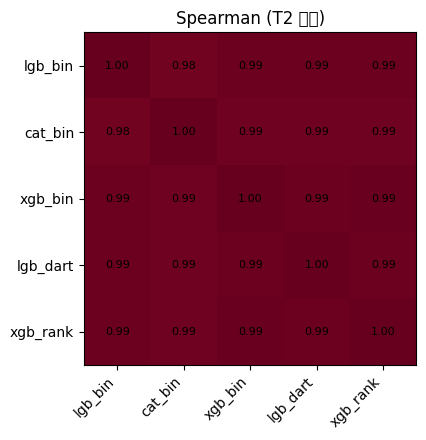

In [8]:
S=pd.DataFrame(oof).corr(method="spearman")
print(S.round(3).to_string())
for m in ["lgb_dart","xgb_rank"]:
    mx=max(S.loc[m,b] for b in ["lgb_bin","cat_bin","xgb_bin"])
    print(f"  {m}: 트리 대비 최대 Spearman={mx:.3f} {'(decorrelated)' if mx<=0.95 else '(중복)'}")
fig,ax=plt.subplots(figsize=(5.5,4.5)); im=ax.imshow(S,cmap='RdBu_r',vmin=0,vmax=1)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names,rotation=45,ha='right'); ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)): ax.text(j,i,f"{S.iloc[i,j]:.2f}",ha='center',va='center',fontsize=8)
plt.title("Spearman (T2 포함)"); plt.tight_layout(); plt.show()

## 7. 블렌드 + 게이트 — 3트리 vs +T2 (증분 페어드 부트스트랩)

In [9]:
def hill(oofd,yy,n_iter=80):
    nm=list(oofd); sing={n:roc_auc_score(yy,oofd[n]) for n in nm}; b0=max(sing,key=sing.get)
    ens=[b0]; s=oofd[b0].copy(); snaps=[(list(ens),roc_auc_score(yy,s/len(ens)))]
    for _ in range(n_iter):
        cb,ca=None,-1
        for n in nm:
            a=roc_auc_score(yy,(s+oofd[n])/(len(ens)+1))
            if a>ca: ca,cb=a,n
        ens.append(cb); s=s+oofd[cb]; snaps.append((list(ens),roc_auc_score(yy,s/len(ens))))
    be,ba=max(snaps,key=lambda t:t[1])
    from collections import Counter; c=Counter(be)
    return {n:c.get(n,0)/len(be) for n in nm},ba,b0

base3={m:oof[m] for m in ["lgb_bin","cat_bin","xgb_bin"]}
w3,bl3,_=hill(base3,y); blend3=sum(w3[m]*base3[m] for m in w3)
wN,blN,_=hill(oof,y);   blendN=sum(wN[m]*oof[m] for m in wN)
print(f"3트리 블렌드 OOF = {bl3:.5f}")
print(f"+T2 전체 블렌드 OOF = {blN:.5f}  | Δ = {blN-bl3:+.5f}")
print("  가중치:",{k:round(v,3) for k,v in wN.items() if v>0})
t2w=sum(wN[m] for m in ["lgb_dart","xgb_rank"])
print(f"  T2 변이 총 가중치 = {t2w:.3f}  {'(기여)' if t2w>0.02 else '(≈0: T2 무용)'}")
rng=np.random.default_rng(0); idx=np.arange(len(y)); ds=[]
for _ in range(BOOT_N):
    s=rng.choice(idx,len(idx),replace=True); ds.append(roc_auc_score(y[s],blendN[s])-roc_auc_score(y[s],blend3[s]))
lo,hi=np.percentile(ds,[2.5,97.5])
print(f"\n증분 95%CI = [{lo:+.5f}, {hi:+.5f}], 평균 {np.mean(ds):+.5f}")
print("판정:", "채택 후보 (CI>0 → FAST→FULL/멀티시드/LB로 확정)" if lo>0 else "채택 안 함 (CI가 0 포함 = 노이즈)")

3트리 블렌드 OOF = 0.73952
+T2 전체 블렌드 OOF = 0.73953  | Δ = +0.00001
  가중치: {'lgb_bin': 0.421, 'cat_bin': 0.228, 'xgb_bin': 0.263, 'xgb_rank': 0.088}
  T2 변이 총 가중치 = 0.088  (기여)

증분 95%CI = [-0.00001, +0.00003], 평균 +0.00001
판정: 채택 안 함 (CI가 0 포함 = 노이즈)


## 8. (선택) 멀티시드 게이트 — `RUN_MULTISEED=True`일 때만

6멤버를 seed (42,7,2024)로 재학습해 증분 mean±std. **매우 무거움.**

In [10]:
if RUN_MULTISEED:
    rows=[]
    for s in (42,7,2024):
        fd=list(StratifiedKFold(N_SPLITS,shuffle=True,random_state=s).split(train,y))
        o,_,_=members_oof(train,test,fd,cats,Xtr,Xte,FAST)
        b3={m:o[m] for m in ["lgb_bin","cat_bin","xgb_bin"]}
        _w3,_b3,_=hill(b3,y); _bl3=sum(_w3[m]*b3[m] for m in _w3)
        _wN,_bN,_=hill(o,y);  _blN=sum(_wN[m]*o[m] for m in _wN)
        rows.append({"seed":s,"d":round(_bN-_bl3,5)}); print(f"  seed{s}: Δ={_bN-_bl3:+.5f}")
    r=pd.DataFrame(rows); print(f"\n증분 mean±std = {r['d'].mean():+.5f} ± {r['d'].std():.5f} → {'채택후보' if r['d'].mean()>r['d'].std() else '노이즈'}")
else:
    print("RUN_MULTISEED=False — seed42 게이트 먼저. 확정 시 True로.")

RUN_MULTISEED=False — seed42 게이트 먼저. 확정 시 True로.


## 9. 산출물 — 제출 + OOF 저장

In [11]:
def write_sub(pred,name):
    s=sample_sub.copy() if sample_sub is not None else pd.DataFrame({ID_COL:test[ID_COL].values})
    pc=[c for c in s.columns if c!=ID_COL]; pc=pc[0] if pc else "probability"
    pm=dict(zip(test[ID_COL].values,pred))
    if ID_COL in s.columns: s[pc]=s[ID_COL].map(pm)
    else: s[ID_COL]=test[ID_COL].values; s[pc]=pred
    s.to_csv(name,index=False); return s,pc

test_blendN=sum(wN[m]*tst[m] for m in wN)
sub,pc=write_sub(test_blendN,"submission_t2.csv")
pd.DataFrame({**{f"oof_{m}":oof[m] for m in names},"y":y}).to_csv("oof_t2.csv",index=False)
pd.DataFrame({**{f"test_{m}":tst[m] for m in names}}).assign(ID=test[ID_COL].values).to_csv("test_t2.csv",index=False)
print("submission_t2.csv:",sub.shape,"| 결측",int(sub[pc].isna().sum()))
print("oof_t2.csv / test_t2.csv 저장(랭크 정규화된 6멤버, 재사용용)")
sub.head()

submission_t2.csv: (90067, 2) | 결측 0
oof_t2.csv / test_t2.csv 저장(랭크 정규화된 6멤버, 재사용용)


,ID,probability
0,TEST_00000,0.080902
1,TEST_00001,0.066588
2,TEST_00002,0.258334
3,TEST_00003,0.200774
4,TEST_00004,0.963675


## 10. 결정

- **단일(5절):** 랭킹/DART가 최강 binary 단일을 **유의하게 넘으면** → 그 자체로 멤버 가치 + AUC 직접최적화 효과 입증.
- **게이트(7절):** 증분 **CI>0** AND FAST→FULL 안정 AND (확정 시)멀티시드 Δ>std → **채택 후보**. 그다음 LB 1회로 확인.
- **CI가 0 포함 / T2 가중치≈0** → "랭킹·DART로도 천장 안 바뀜" 네거티브로 기록(닫고 T1 NN으로).
- 운영 제출은 **3트리 블렌드(0.74182) 고정**. T2는 게이트+LB 통과 시에만 합류.

> FAST=True로 방향 → FULL(FAST=False) 확정. 무거우면 N_SPLITS만 5로 두고 라운드 조정. GPU 불필요(CPU).